<a href="https://colab.research.google.com/github/hwanginseo04/-/blob/main/3%EC%9B%9420%EC%9D%BC%EB%8D%B0%EC%9D%B4%ED%84%B0_%EA%B4%80%EB%A6%AC%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_870/2168768293.py:18: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_870/2168768293.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_870/2168768293.py:18: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_870/2168768293.py:18: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_870/2168768293.py:18: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyp

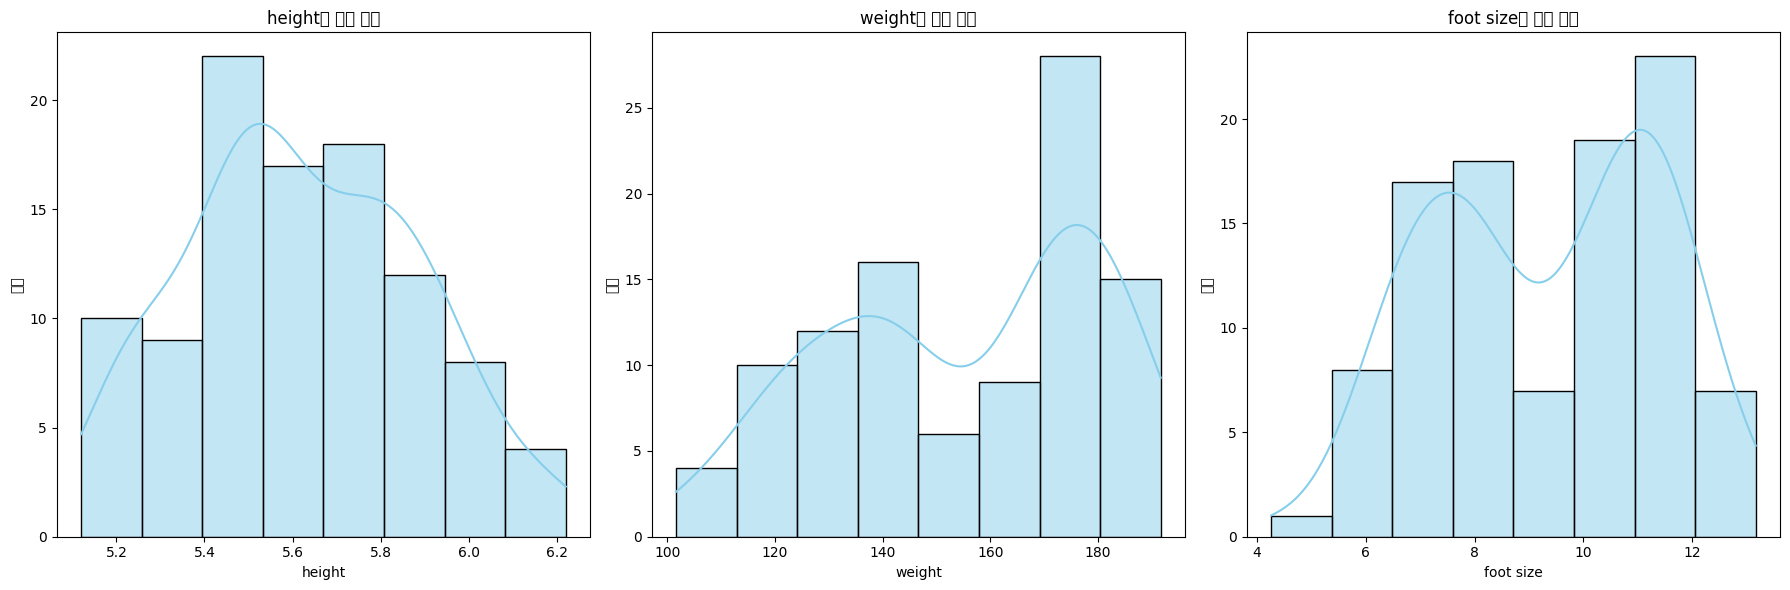

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정이 재실행 후에도 적용되지 않았을 경우를 대비하여 다시 한번 설정합니다.
# 이미 설치된 폰트이므로 이 셀을 실행한 후 런타임을 다시 시작할 필요는 없습니다.
plt.rc('font', family='NanumBarunGothic') # 'NanumBarunGothic' 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

# 히스토그램 그리기
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}의 빈도 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도')

plt.tight_layout()
plt.show()

표준화는 데이터 값을 동일하게 만드는 것이 아니라,
비교 기준을 같게 만들어 분석을 쉽게 하는 과정이다.

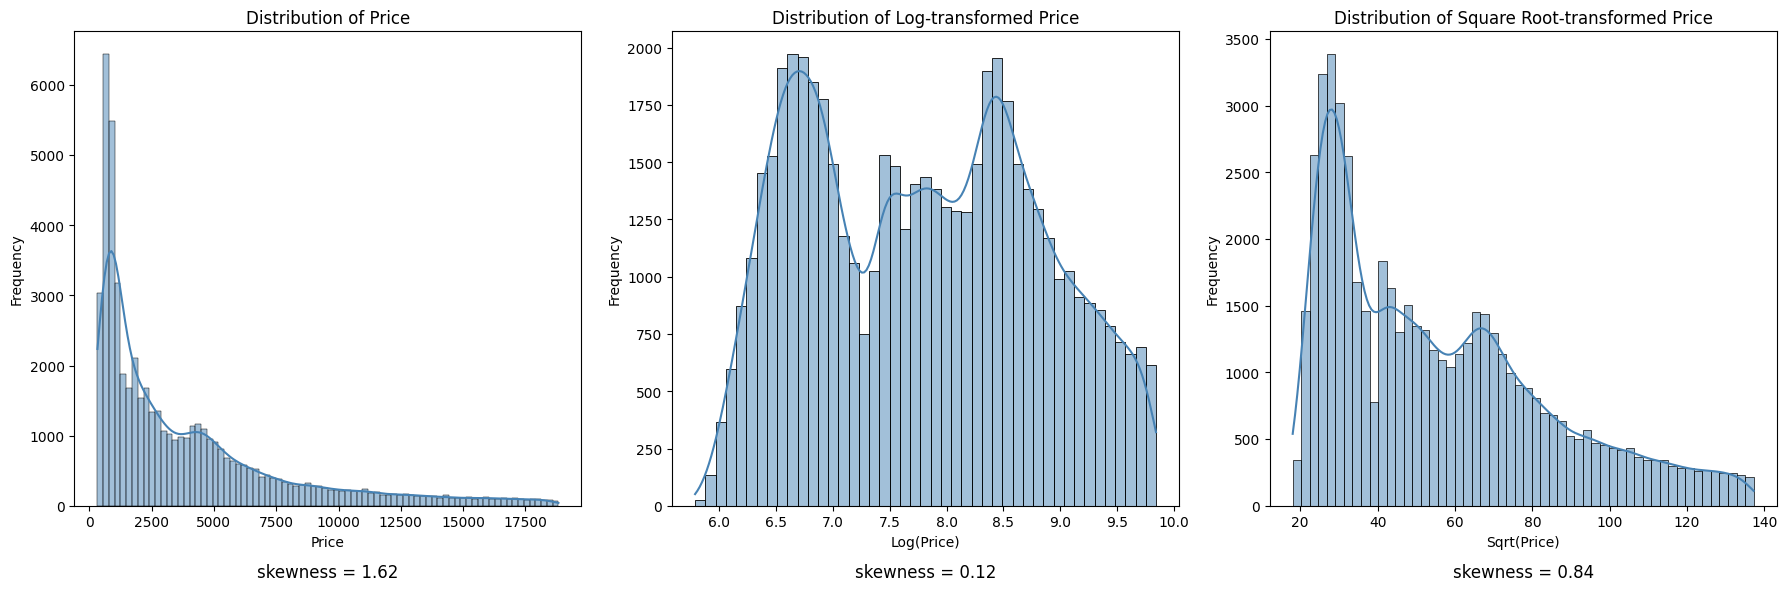

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로드
diamonds = sns.load_dataset("diamonds")
price = diamonds['price']

# 2. 데이터 변환 수행
log_price = np.log(price)
sqrt_price = np.sqrt(price)

# 3. 그래프 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 첫 번째: 원본 데이터 (Original Price) ---
sns.histplot(price, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
skew_orig = price.skew()
axes[0].text(0.5, -0.15, f'skewness = {skew_orig:.2f}', transform=axes[0].transAxes,
             ha='center', fontsize=12)

# --- 두 번째: 로그 변환 (Log Transformation) ---
sns.histplot(log_price, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Log-transformed Price')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
skew_log = log_price.skew()
axes[1].text(0.5, -0.15, f'skewness = {skew_log:.2f}', transform=axes[1].transAxes,
             ha='center', fontsize=12)

# --- 세 번째: 루트 변환 (Square Root Transformation) ---
sns.histplot(sqrt_price, kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Distribution of Square Root-transformed Price')
axes[2].set_xlabel('Sqrt(Price)')
axes[2].set_ylabel('Frequency')
skew_sqrt = sqrt_price.skew()
axes[2].text(0.5, -0.15, f'skewness = {skew_sqrt:.2f}', transform=axes[2].transAxes,
             ha='center', fontsize=12)

plt.tight_layout()
plt.show()

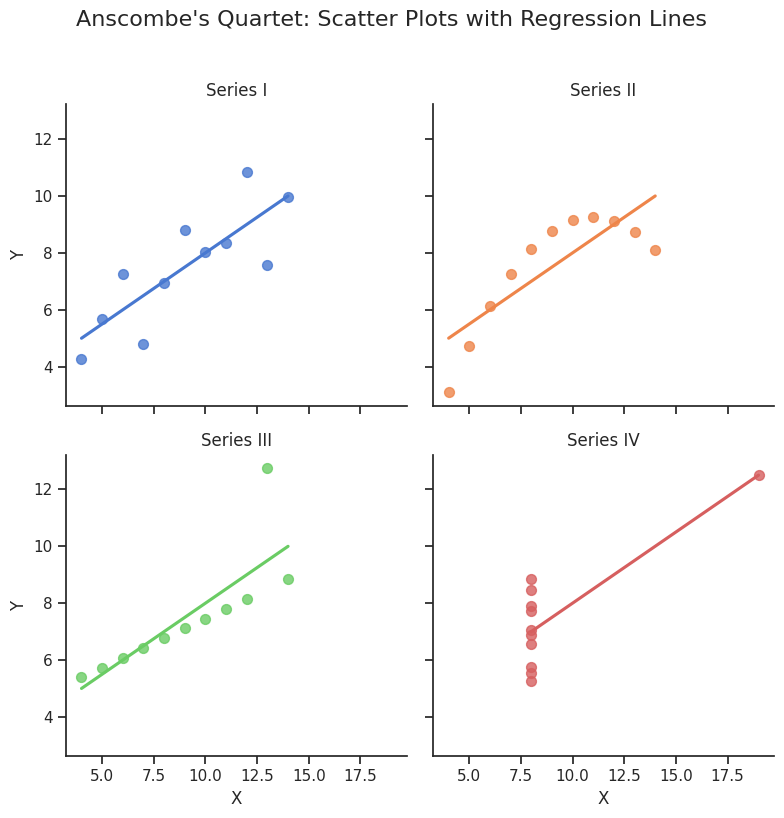

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# anscombe.json 파일 로드 (이전 셀에서 df가 이미 로드되었지만, 명확성을 위해 다시 로드합니다)
file_path = '/content/sample_data/anscombe.json'
df = pd.read_json(file_path)

# Anscombe 데이터셋 시각화
# 각 데이터셋에 대한 산점도와 회귀선 그리기
sns.set_theme(style="ticks")

# FacetGrid를 사용하여 각 'Series'별로 서브플롯 생성
# X와 Y의 관계를 산점도와 회귀선을 통해 시각화합니다.
fig = sns.lmplot(data=df, x="X", y="Y", col="Series", hue="Series", col_wrap=2, ci=None,
               palette="muted", height=4, scatter_kws={"s": 50, "alpha": 0.8})

fig.set_axis_labels("X", "Y")
fig.set_titles("Series {col_name}")

plt.suptitle("Anscombe's Quartet: Scatter Plots with Regression Lines", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

위 그래프는 Anscombe의 콰르텟(Anscombe's Quartet)을 시각화한 결과입니다. 이전에 계산된 평균, 분산, 표준편차, 상관계수와 같은 요약 통계량은 4개의 모든 데이터셋에 대해 거의 동일했습니다.

그러나 시각화를 통해 각 데이터셋이 매우 다른 분포와 패턴을 가지고 있음을 명확히 확인할 수 있습니다:

*   **Series I**: 전형적인 선형 관계를 보입니다.
*   **Series II**: 비선형(곡선) 관계를 보이지만, 회귀선은 여전히 선형으로 추정됩니다.
*   **Series III**: 하나의 아웃라이어(이상치)가 회귀선에 큰 영향을 미치고 있습니다.
*   **Series IV**: X 값이 거의 동일한 하나의 점을 제외하고는 모든 점이 같은 X 값에 집중되어 있으며, 이 하나의 점이 회귀선의 기울기를 결정하는 데 큰 역할을 합니다.

이것은 요약 통계량만으로는 데이터의 본질적인 특성을 완전히 파악하기 어렵다는 것을 보여주는 중요한 예시이며, 데이터 분석에서 시각화가 필수적인 이유를 설명해 줍니다.